Implement and compare RNN, LSTM, and GRU models for sequence classification, and analyze their performance using appropriate evaluation metrics.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Number of most frequent words
vocab_size = 10000

# Maximum sequence length
max_length = 200

# Load IMDB dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("First review:", X_train[0][:20])
print("First label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First label: 1


In [3]:
# Make all sequences the same length
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)


In [4]:
def create_rnn_model():

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=64),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


rnn_model = create_rnn_model()

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

rnn_time = time.time() - start_time

print("RNN Training Time:", round(rnn_time, 2), "seconds")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.4971 - loss: 0.6995 - val_accuracy: 0.4978 - val_loss: 0.6943
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.5804 - loss: 0.6705 - val_accuracy: 0.5056 - val_loss: 0.6987
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.6595 - loss: 0.5892 - val_accuracy: 0.5068 - val_loss: 0.7445
RNN Training Time: 52.02 seconds


In [6]:
def create_lstm_model():

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=64),
        LSTM(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


lstm_model = create_lstm_model()

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

lstm_time = time.time() - start_time

print("LSTM Training Time:", round(lstm_time, 2), "seconds")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 310ms/step - accuracy: 0.5253 - loss: 0.6910 - val_accuracy: 0.5382 - val_loss: 0.6855
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 299ms/step - accuracy: 0.5633 - loss: 0.6779 - val_accuracy: 0.5444 - val_loss: 0.6832
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 303ms/step - accuracy: 0.6209 - loss: 0.6185 - val_accuracy: 0.6402 - val_loss: 0.6237
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.6223 - loss: 0.6399 - val_accuracy: 0.6122 - val_loss: 0.6194
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 459ms/step - accuracy: 0.7477 - loss: 0.5207 - val_accuracy: 0.8100 - val_loss: 0.4762
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 336ms/step - accuracy: 0.8454 - loss: 0.4111 - val_accuracy: 0.7906 - val_loss: 0.5101
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 310ms/step - accuracy: 0.8396 - loss: 0.4288 - val_accuracy: 0.7800 - val_loss: 0.5413
LSTM Training Time: 367.12 seconds


In [8]:
def create_gru_model():

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=64),
        GRU(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


gru_model = create_gru_model()

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

gru_time = time.time() - start_time

print("GRU Training Time:", round(gru_time, 2), "seconds")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 353ms/step - accuracy: 0.5099 - loss: 0.6926 - val_accuracy: 0.5262 - val_loss: 0.6905
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 361ms/step - accuracy: 0.5725 - loss: 0.6769 - val_accuracy: 0.5480 - val_loss: 0.6816
GRU Training Time: 114.34 seconds


In [10]:
def evaluate_model(model, X_test, y_test, model_name):

    probabilities = model.predict(X_test, verbose=0)

    predictions = (
        probabilities >= 0.5
    ).astype(int).flatten()

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Negative", "Positive"]
        )
    )

    return [
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ]

In [11]:
rnn_results = evaluate_model(
    rnn_model,
    X_test,
    y_test,
    "RNN"
)

lstm_results = evaluate_model(
    lstm_model,
    X_test,
    y_test,
    "LSTM"
)

gru_results = evaluate_model(
    gru_model,
    X_test,
    y_test,
    "GRU"
)


RNN
Accuracy : 0.5011
Precision: 0.5021
Recall   : 0.2572
F1 Score : 0.3402

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.74      0.60     12500
    Positive       0.50      0.26      0.34     12500

    accuracy                           0.50     25000
   macro avg       0.50      0.50      0.47     25000
weighted avg       0.50      0.50      0.47     25000


LSTM
Accuracy : 0.7965
Precision: 0.7495
Recall   : 0.8906
F1 Score : 0.814

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.70      0.78     12500
    Positive       0.75      0.89      0.81     12500

    accuracy                           0.80     25000
   macro avg       0.81      0.80      0.79     25000
weighted avg       0.81      0.80      0.79     25000


GRU
Accuracy : 0.5288
Precision: 0.5174
Recall   : 0.8565
F1 Score : 0.6451

Classification Report:
              precision    recall  f1-score

In [12]:
results = pd.DataFrame(
    [
        rnn_results,
        lstm_results,
        gru_results
    ],
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,RNN,0.50108,0.502108,0.25720,0.340158
1,LSTM,0.79648,0.749529,0.89056,0.813981
2,GRU,0.52880,0.517398,0.85648,0.645095


In [13]:
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Training Time (seconds)": [
        rnn_time,
        lstm_time,
        gru_time
    ],
    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

comparison

,Model,Training Time (seconds),Parameters
0,RNN,52.024832,648321
1,LSTM,367.123895,673089
2,GRU,114.344806,665025


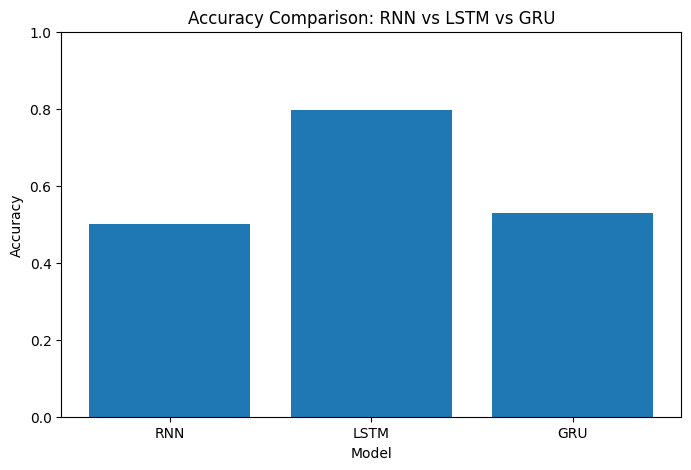

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Accuracy Comparison: RNN vs LSTM vs GRU")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

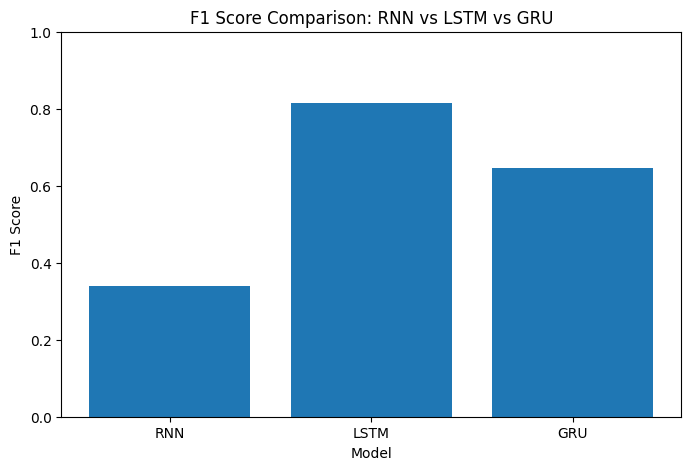

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("F1 Score Comparison: RNN vs LSTM vs GRU")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

plt.show()

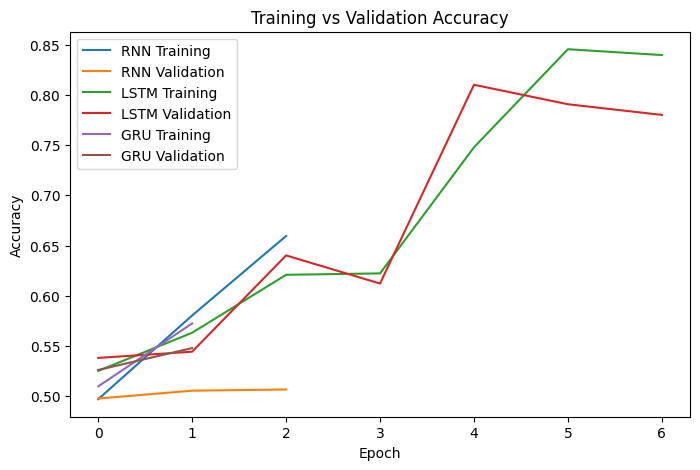

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history.history["accuracy"],
    label="RNN Training"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="RNN Validation"
)

plt.plot(
    lstm_history.history["accuracy"],
    label="LSTM Training"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="LSTM Validation"
)

plt.plot(
    gru_history.history["accuracy"],
    label="GRU Training"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="GRU Validation"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

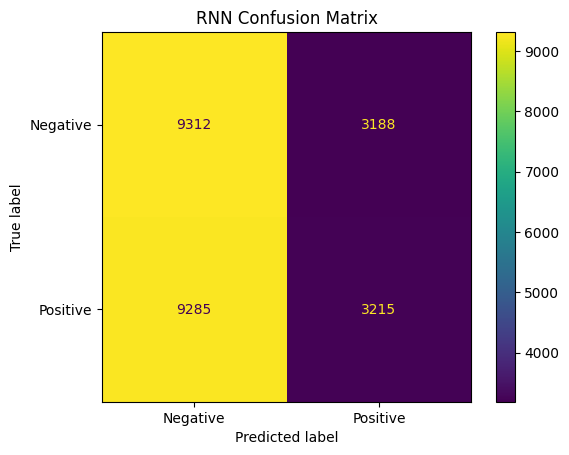

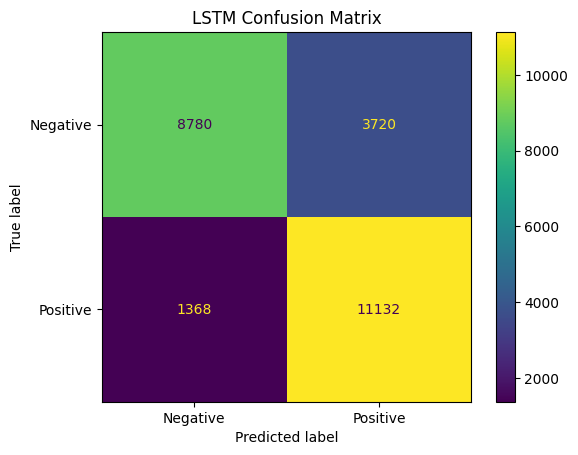

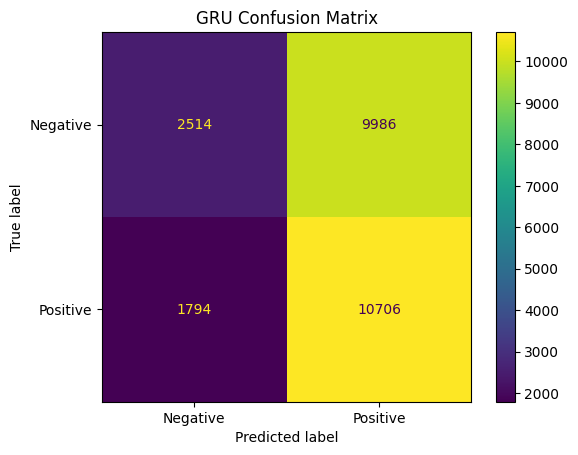

In [17]:
models = [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("GRU", gru_model)
]

for name, model in models:

    probabilities = model.predict(X_test, verbose=0)

    predictions = (
        probabilities >= 0.5
    ).astype(int).flatten()

    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot()
    plt.title(name + " Confusion Matrix")
    plt.show()

In [18]:
best_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("F1 Score:", round(best_model["F1 Score"], 4))

Best Model: LSTM
Accuracy: 0.7965
Precision: 0.7495
Recall: 0.8906
F1 Score: 0.814
